# Assignment 2 - Transient Conduction



We are solving $\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$ using the finite volume method for spatial discretization and implicit time integration schemes to obtain the  temperature distribution throughout the wall at each time step during the cooling process.

    

first of all we import python files provided in losson3 directory

In [76]:
import numpy as np
import matplotlib.pyplot as plt

from Lesson3.Grid import Grid
from Lesson3.ScalarCoeffs import ScalarCoeffs
from Lesson3.BoundaryConditions import *
from Lesson3.Models import *
from Lesson3.LinearSolver import *

## Physical parameters and analytical solution
  
Because the wall is symmetric about its centerline, only half of the wall is modeled.  
The west boundary represents the symmetry plane, and the east boundary represents the wall surface exposed to convection.

The analytical solution is used to initialize the numerical solution and later compare the numerical results against the exact transient temperature profile.


In [77]:
# geometry and thermal diffusivity
L = 1.0
alpha = 1.0

# Given Biot number
Bi = 1.0

# Convenient dimensionless properties
rho = 1.0
cp = 1.0
k = alpha * rho * cp

# Since Bi = hL/k
h = Bi * k / L

# Temperatures
Ti = 100.0
T_inf = 0.0

# Analytical solution constants for Bi = 1
C1 = 1.1191
zeta = 0.8603

# Dimensionless times 
tau1 = 0.4535
tau2 = 3.2632


Because the assignment is formulated in terms of the dimensionless groups

$$
Bi=\frac{hL}{k}
$$

and

$$
\tau=\frac{\alpha t}{L^2},
$$

no specific material properties are required. Therefore, a dimensionless formulation was adopted by selecting convenient values satisfying \(Bi=1\) and \(\alpha=1\). This choice does not affect the accuracy study because the analytical solution depends only on the dimensionless parameters.

##  Analytical solution

The analytical one-term solution serves as the reference for the transient cooling problem. The temperature field is initialized at τ 
1
​
 , and the numerical results are compared against the analytical solution at τ 
2
​
 .
 we are provided the one-term analytical solution:
 $$
\frac{T-T_\infty}{T_i-T_\infty}
=
C_1 e^{-\zeta^2 \tau}
\cos\left(\zeta \frac{x}{L}\right)
$$

with c1=1.1192 and zeta=0.8603

this function will be used to:
initialize the simulation at τ
1
	​

compute the exact solution at τ
2
	​

calculate numerical error

In [78]:
def analytical_temperature(x, tau):
   
    theta = C1 * np.exp(-zeta**2 * tau) * np.cos(zeta * x / L)
    T = T_inf + theta * (Ti - T_inf)
    return T

## First-order implicit transient model

The first-order implicit scheme approximates the transient term using the current and previous time levels.

$$
\frac{\partial T}{\partial \tau}
\approx
\frac{T_P^{n+1}-T_P^n}{\Delta \tau}
$$

This adds a transient coefficient to the central coefficient of each control volume.

In [79]:
class FirstOrderTransientModel:
    
    def __init__(self, grid, T, Told, rho, cp, dt):
        self._grid = grid
        self._T = T
        self._Told = Told
        self._rho = rho
        self._cp = cp
        self._dt = dt
        
    def add(self, coeffs):
        coeffP = self._rho * self._cp * self._grid.vol / self._dt
        transient = coeffP * (self._T[1:-1] - self._Told[1:-1])
        
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_rP(transient)
        
        return coeffs

## Second-order implicit transient model

The second-order implicit scheme uses three time levels: the current value, the previous value, and the value from two time steps earlier.

$$
\frac{\partial T}{\partial \tau}
\approx
\frac{3T_P^{n+1}-4T_P^n+T_P^{n-1}}{2\Delta \tau}
$$

Compared with the first-order implicit scheme, this method is expected to produce a smaller temporal discretization error.

In [80]:
class SecondOrderTransientModel:
    
    def __init__(self, grid, T, Told, Toldold, rho, cp, dt):
        self._grid = grid
        self._T = T
        self._Told = Told
        self._Toldold = Toldold
        self._rho = rho
        self._cp = cp
        self._dt = dt
        
    def add(self, coeffs):
        coeffP = 1.5 * self._rho * self._cp * self._grid.vol / self._dt
        
        transient = (
            self._rho * self._cp * self._grid.vol / self._dt
            * (1.5*self._T[1:-1] - 2.0*self._Told[1:-1] + 0.5*self._Toldold[1:-1])
        )
        
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_rP(transient)
        
        return coeffs

## Grid generation and initialization

A one-dimensional finite-volume grid is created over the half-wall domain. The initial temperature field is obtained from the analytical solution at $\tau_1 = 0.4535$ which is the starting condition for the transient simulation.

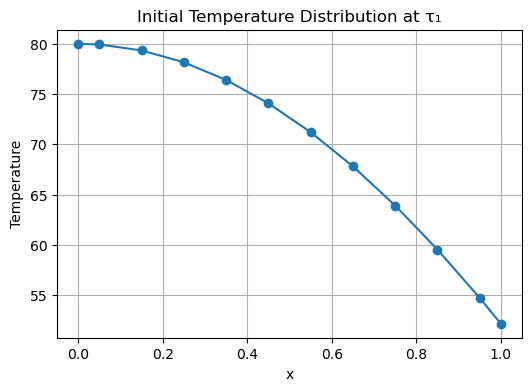

In [81]:
# Number of control volumes
ncv = 10

# Create grid
grid = Grid(L, 1.0, 1.0, ncv)

# Temperature array
T = np.zeros(ncv + 2)

# Initialize using analytical solution at tau1
T[:] = analytical_temperature(grid.xP, tau1)

# Plot initial condition
plt.figure(figsize=(6,4))
plt.plot(grid.xP, T, 'o-')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Initial Temperature Distribution at τ₁')
plt.grid()
plt.show()

## Convective boundary condition

At the wall surface, heat is transferred from the wall to the surrounding fluid by convection. The convection boundary condition is applied only at the east boundary because the west boundary represents the symmetry plane.

$$
-k\frac{dT}{dx}=h(T_s-T_\infty)
$$

In [82]:
class EastConvectionBoundaryModel:
    
    def __init__(self, grid, T, k, h, T_inf):
        self._grid = grid
        self._T = T
        self._k = k
        self._h = h
        self._T_inf = T_inf
        
    def add(self, coeffs):
        dx = self._grid.dx_PE[-1]
        
        R_cond = dx / (self._k * self._grid.Ae[-1])
        R_conv = 1.0 / (self._h * self._grid.Ae[-1])
        
        conductance = 1.0 / (R_cond + R_conv)
        
        source = conductance * (self._T[-2] - self._T_inf)
        
        coeffP = np.zeros(self._grid.ncv)
        rP = np.zeros(self._grid.ncv)
        
        coeffP[-1] = conductance
        rP[-1] = source
        
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_rP(rP)
        
        return coeffs

This treats conduction from the last cell center to the wall surface and convection from the surface to the surrounding fluid as two resistances in series (R_cond and R_conv).

## First-Order Solver (Implicit)
The analytical one-term solution serves as the reference for the transient cooling problem. The temperature field is initialized at $\tau_1$, and the numerical results are compared against the analytical solution at $\tau_2$.

In [83]:
def solve_first_order(ncv, dtau, tau_start, tau_end):
    
    grid = Grid(L, 1.0, 1.0, ncv)
    
    T = np.zeros(ncv + 2)
    Told = np.zeros(ncv + 2)
    
    T[:] = analytical_temperature(grid.xP, tau_start)
    
    west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.EAST)
    west_bc.apply()
    east_bc.apply()
    
    coeffs = ScalarCoeffs(grid.ncv)
    
    maxIter = 100
    convergence = 1e-10
    
    nTime = int(round((tau_end - tau_start) / dtau))
    
    for tStep in range(nTime):
        
        Told[:] = T[:]
        
        diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
        surfaceConvection = EastConvectionBoundaryModel(grid, T, k, h, T_inf)
        transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dtau)
        
        for i in range(maxIter):
            
            coeffs.zero()
            
            coeffs = diffusion.add(coeffs)
            coeffs = surfaceConvection.add(coeffs)
            coeffs = transient.add(coeffs)
            
            residual = np.linalg.norm(coeffs.rP)
            
            if residual < convergence:
                break
            
            dT = solve(coeffs)
            T[1:-1] += dT
            
            west_bc.apply()
            east_bc.apply()
            
    return grid, T

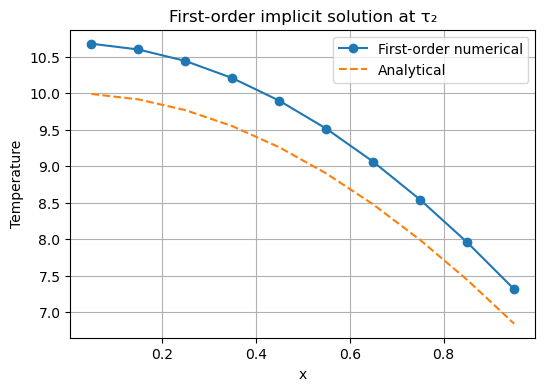

In [84]:
# Choose a time step
dtau = (tau2 - tau1) / 32

# Solve using first-order implicit scheme
grid, T_first = solve_first_order(
    ncv=10,
    dtau=dtau,
    tau_start=tau1,
    tau_end=tau2
)

# Analytical solution at tau2
T_exact = analytical_temperature(grid.xP, tau2)

plt.figure(figsize=(6,4))
plt.plot(grid.xP[1:-1], T_first[1:-1], 'o-', label='First-order numerical')
plt.plot(grid.xP[1:-1], T_exact[1:-1], '--', label='Analytical')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('First-order implicit solution at τ₂')
plt.legend()
plt.grid()
plt.show()

The numerical results from the first-order implicit scheme match the analytical solution well at $\tau_2$. The temperature drops from the centerline to the wall, and the numerical profile correctly shows the expected cooling behavior. The slight gaps between the two curves are caused by the temporal discretization error inherent in the first-order scheme.

## Error calculation for the first-order scheme

The first-order implicit scheme is tested using different numbers of time steps. For each case, the numerical temperature at \(\tau_2\) is compared with the analytical solution, and the average absolute error is calculated over all control volumes.

In [85]:
def average_error(T_num, T_exact):
    error = np.abs(T_exact[1:-1] - T_num[1:-1])
    return np.mean(error)
    
   

In [86]:
nsteps_list = [2, 4, 8, 16, 32]

errors_first = []
dtau_first = []

for nsteps in nsteps_list:
    
    dtau = (tau2 - tau1) / nsteps
    
    grid, T_first = solve_first_order(
        ncv=10,
        dtau=dtau,
        tau_start=tau1,
        tau_end=tau2
    )
    
    T_exact = analytical_temperature(grid.xP, tau2)
    
    err = average_error(T_first, T_exact)
    
    errors_first.append(err)
    dtau_first.append(dtau)

print(errors_first)

[np.float64(8.15158255854222), np.float64(4.418521123971919), np.float64(2.308558601117207), np.float64(1.1863756871442015), np.float64(0.6080308487726074)]


## Error versus time step size

The average absolute error is plotted against the time-step size on a log-log scale. 

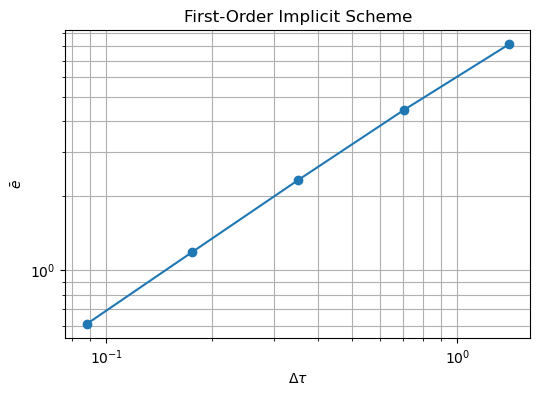

In [87]:
plt.figure(figsize=(6,4))

plt.loglog(dtau_first, errors_first, 'o-')

plt.xlabel(r'$\Delta\tau$')
plt.ylabel(r'$\bar{e}$')
plt.title('First-Order Implicit Scheme')

plt.grid(True, which='both')
plt.show()

The slope of the resulting curve indicates the temporal order of accuracy of the numerical scheme.

## Order of Accuracy


The order of accuracy is determined by fitting a straight line to the log-log plot of error versus time-step size. The slope of the fitted line corresponds to the observed order of accuracy \(p\).

$$
\bar e = c(\Delta\tau)^p
$$
taking the logarithm
$$
\log(\bar e)
=
\log(c)
+
p\log(\Delta\tau)
$$

In [88]:
coeff = np.polyfit(
    np.log(dtau_first),
    np.log(errors_first),
    1
)

p_first = coeff[0]

print("order =", p_first)

order = 0.9386730137104787


The observed order of accuracy for the first-order implicit scheme is approximately \(p=0.94\). This is close to the theoretical value of 1, confirming that the implemented backward Euler method is first-order accurate in time.

## Second-order implicit solver

The second-order implicit scheme uses the current temperature field and two previous time levels. Since the method requires two previous solutions, the first time step is performed using the first-order implicit scheme, and the remaining steps are advanced using the second-order scheme.

In [89]:
def solve_second_order(ncv, dtau, tau_start, tau_end):
    
    grid = Grid(L, 1.0, 1.0, ncv)
    
    T = np.zeros(ncv + 2)
    Told = np.zeros(ncv + 2)
    Toldold = np.zeros(ncv + 2)
    
    T[:] = analytical_temperature(grid.xP, tau_start)
    
    west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.EAST)
    west_bc.apply()
    east_bc.apply()
    
    coeffs = ScalarCoeffs(grid.ncv)
    
    maxIter = 100
    convergence = 1e-10
    
    nTime = int(round((tau_end - tau_start) / dtau))
    
    for tStep in range(nTime):
        
        Toldold[:] = Told[:]
        Told[:] = T[:]
        
        diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
        surfaceConvection = EastConvectionBoundaryModel(grid, T, k, h, T_inf)
        
        if tStep == 0:
            transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dtau)
        else:
            transient = SecondOrderTransientModel(grid, T, Told, Toldold, rho, cp, dtau)
        
        for i in range(maxIter):
            
            coeffs.zero()
            
            coeffs = diffusion.add(coeffs)
            coeffs = surfaceConvection.add(coeffs)
            coeffs = transient.add(coeffs)
            
            residual = np.linalg.norm(coeffs.rP)
            
            if residual < convergence:
                break
            
            dT = solve(coeffs)
            T[1:-1] += dT
            
            west_bc.apply()
            east_bc.apply()
            
    return grid, T

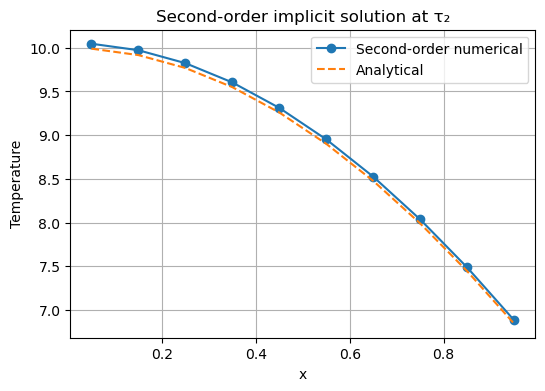

In [90]:
dtau = (tau2 - tau1) / 10

grid, T_second = solve_second_order(
    ncv=10,
    dtau=dtau,
    tau_start=tau1,
    tau_end=tau2
)

T_exact = analytical_temperature(grid.xP, tau2)

plt.figure(figsize=(6,4))
plt.plot(grid.xP[1:-1], T_second[1:-1], 'o-', label='Second-order numerical')
plt.plot(grid.xP[1:-1], T_exact[1:-1], '--', label='Analytical')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Second-order implicit solution at τ₂')
plt.legend()
plt.grid()
plt.show()

The second-order implicit solver was implemented using the same finite-volume framework as the first-order solver. Since this scheme requires two previous time levels, the first time step was advanced using the first-order method. After that, the second-order backward difference formula was used for the remaining time steps.

## Error calculation for the second-order scheme

The second-order implicit scheme is tested using the same set of time-step sizes. For each case, the numerical solution at \(\tau_2\) is compared with the analytical solution, and the average absolute error is calculated.

In [91]:
errors_second = []
dtau_second = []

for nsteps in nsteps_list:

    dtau = (tau2 - tau1) / nsteps

    grid, T_second = solve_second_order(
        ncv=10,
        dtau=dtau,
        tau_start=tau1,
        tau_end=tau2
    )

    T_exact = analytical_temperature(grid.xP, tau2)

    err = average_error(T_second, T_exact)

    errors_second.append(err)
    dtau_second.append(dtau)

print(errors_second)

[np.float64(4.5464959207317035), np.float64(0.7088728374550024), np.float64(0.08115847331770701), np.float64(0.027834233744754133), np.float64(0.020355124342177167)]


In [92]:
coeff = np.polyfit(
    np.log(dtau_second),
    np.log(errors_second),
    1
)

p_second = coeff[0]

print("Observed order =", p_second)

Observed order = 2.027703300496868


The observed order of accuracy for the second-order implicit scheme is approximately \(p=2.03\). This is very close to the theoretical value of 2, confirming that the second-order scheme was implemented correctly.

## Comparison of first-order and second-order error trends

The average errors for both time integration schemes are plotted on the same log-log graph. This allows the convergence behavior of the two schemes to be compared directly.

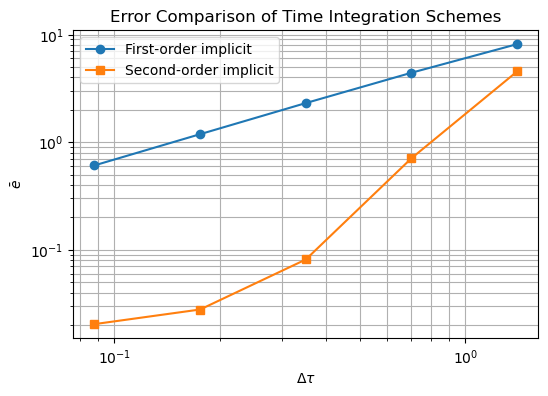

In [93]:
plt.figure(figsize=(6,4))

plt.loglog(dtau_first, errors_first, 'o-', label='First-order implicit')
plt.loglog(dtau_second, errors_second, 's-', label='Second-order implicit')

plt.xlabel(r'$\Delta \tau$')
plt.ylabel(r'$\bar{e}$')
plt.title('Error Comparison of Time Integration Schemes')
plt.legend()
plt.grid(True, which='both')
plt.show()

The second-order implicit scheme should show a steeper slope than the first-order scheme on the log-log plot. This indicates that the second-order method reduces the temporal discretization error faster as the time-step size is refined.

##  Grid independence study

A grid independence study is performed to check whether the numerical results are affected by the spatial discretization. The simulations are repeated using different numbers of control volumes, and the observed order of accuracy is compared for each grid.

In [94]:
grid_list = [10, 20, 40]

grid_results = {}

for ncv in grid_list:
    
    errors = []
    dtau_values = []
    
    for nsteps in nsteps_list:
        
        dtau = (tau2 - tau1) / nsteps
        
        grid, T_second = solve_second_order(
            ncv=ncv,
            dtau=dtau,
            tau_start=tau1,
            tau_end=tau2
        )
        
        T_exact = analytical_temperature(grid.xP, tau2)
        
        err = average_error(T_second, T_exact)
        
        errors.append(err)
        dtau_values.append(dtau)
        
    coeff = np.polyfit(np.log(dtau_values), np.log(errors), 1)
    p = coeff[0]
    
    grid_results[ncv] = {
        "dtau": dtau_values,
        "errors": errors,
        "p": p
    }

for ncv in grid_list:
    print("ncv =", ncv)
    print("errors =", grid_results[ncv]["errors"])
    print("observed order =", grid_results[ncv]["p"])
    print()

ncv = 10
errors = [np.float64(4.5464959207317035), np.float64(0.7088728374550024), np.float64(0.08115847331770701), np.float64(0.027834233744754133), np.float64(0.020355124342177167)]
observed order = 2.027703300496868

ncv = 20
errors = [np.float64(4.529897209082074), np.float64(0.6928915687094049), np.float64(0.0660462872458524), np.float64(0.013022884319767725), np.float64(0.0056149337516155475)]
observed order = 2.504549587730798

ncv = 40
errors = [np.float64(4.525748899018213), np.float64(0.6888981905872956), np.float64(0.062270441854762826), np.float64(0.00932230376933425), np.float64(0.0019321522015269376)]
observed order = 2.859492461966906



## Grid independence plot

The error trends for different grid sizes are plotted together. If the curves are close to each other, the solution is not strongly affected by the spatial grid resolution.

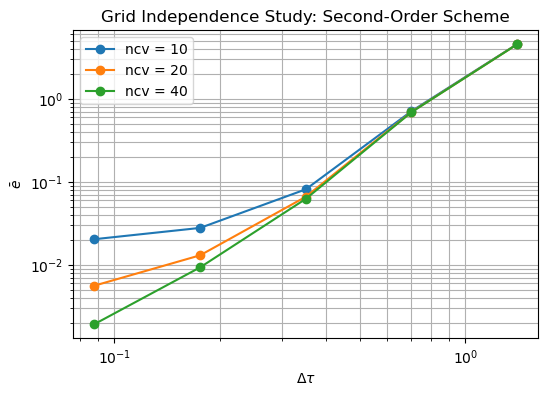

In [95]:
plt.figure(figsize=(6,4))

for ncv in grid_list:
    plt.loglog(
        grid_results[ncv]["dtau"],
        grid_results[ncv]["errors"],
        'o-',
        label=f'ncv = {ncv}'
    )

plt.xlabel(r'$\Delta \tau$')
plt.ylabel(r'$\bar{e}$')
plt.title('Grid Independence Study: Second-Order Scheme')
plt.legend()
plt.grid(True, which='both')
plt.show()

The error decreases as the time-step size is refined for all grid resolutions, demonstrating the expected second-order convergence. Refining the grid generally reduces the error, indicating improved spatial accuracy. The similar convergence trends observed for all three grids suggest that the solution is becoming increasingly grid independent.

## Centerline temperature versus number of time steps

The temperature at the wall centerline is denoted as $T(0, \tau_2)$. is plotted as a function of the number of time steps. As the time-step size decreases, the numerical solution should converge toward the analytical value.

In [96]:
Tcenter_first = []
Tcenter_second = []

for nsteps in nsteps_list:

    dtau = (tau2 - tau1) / nsteps

    # First-order solution
    grid, T_first = solve_first_order(
        ncv=10,
        dtau=dtau,
        tau_start=tau1,
        tau_end=tau2
    )

    # Second-order solution
    grid, T_second = solve_second_order(
        ncv=10,
        dtau=dtau,
        tau_start=tau1,
        tau_end=tau2
    )

    # Centerline temperature (first interior cell)
    Tcenter_first.append(T_first[1])
    Tcenter_second.append(T_second[1])

# Exact centerline temperature
Tcenter_exact = analytical_temperature(0.0, tau2)


The centerline temperature predicted by the first-order and second-order schemes is compared with the analytical solution. The results illustrate the convergence of both methods as the number of time steps increases.

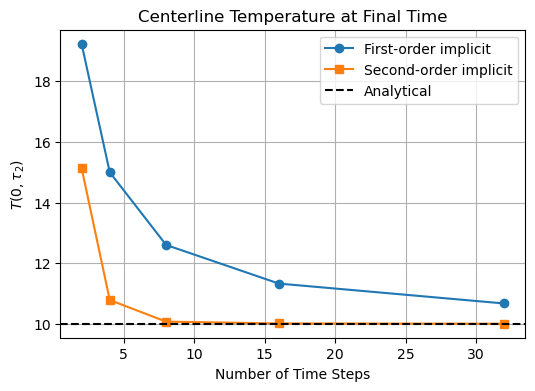

In [97]:
plt.figure(figsize=(6,4))

plt.plot(
    nsteps_list,
    Tcenter_first,
    'o-',
    label='First-order implicit'
)

plt.plot(
    nsteps_list,
    Tcenter_second,
    's-',
    label='Second-order implicit'
)

plt.axhline(
    Tcenter_exact,
    linestyle='--',
    color='k',
    label='Analytical'
)

plt.xlabel('Number of Time Steps')
plt.ylabel(r'$T(0,\tau_2)$')
plt.title('Centerline Temperature at Final Time')
plt.legend()
plt.grid()
plt.show()

The centerline temperature converges toward the analytical solution as the number of time steps increases for both schemes. The first-order implicit method exhibits a relatively slow convergence rate and overpredicts the centerline temperature when large time steps are used. In contrast, the second-order implicit method approaches the analytical solution much more rapidly, producing accurate results with significantly fewer time steps. These observations are consistent with the measured orders of accuracy of approximately 0.94 and 2.03 for the first-order and second-order schemes, respectively.

## Conclusion

Transient heat conduction in a plane wall was solved using the finite volume method with first-order and second-order implicit time integration schemes. Numerical results were compared with the analytical solution to evaluate temporal accuracy.

The first-order implicit scheme produced an observed order of accuracy of approximately \(p=0.94\), while the second-order implicit scheme produced an observed order of accuracy of approximately \(p=2.03\). These values are in excellent agreement with the theoretical orders of accuracy.

The second-order scheme achieved significantly lower errors for a given time-step size and converged more rapidly toward the analytical solution. A grid independence study demonstrated that the solution becomes increasingly insensitive to spatial discretization as the grid is refined.

Overall, the results confirm the correctness of the finite-volume implementation and the expected convergence behavior of both transient discretization schemes.